In [1]:
import pandas as pd

In [6]:
MODEL_PREDS = "results/"
annot_perfile = pd.read_csv("data/annot_perchunk3s_binary.csv",sep =';')


In [7]:
df_vn = pd.read_csv(MODEL_PREDS + "/preds_VroumNET2.csv",sep=',')
df_temp = df_vn
df_temp['basefile'] = 'rien'
for i in range(len(df_temp)):
    df_temp.loc[i,'basefile']= df_temp.loc[i,'filename'][:-8]
cols = ['Engine', 'Confidence','trueEngine']
df_reduit_vn= df_temp.groupby('basefile')[cols].max().reset_index()

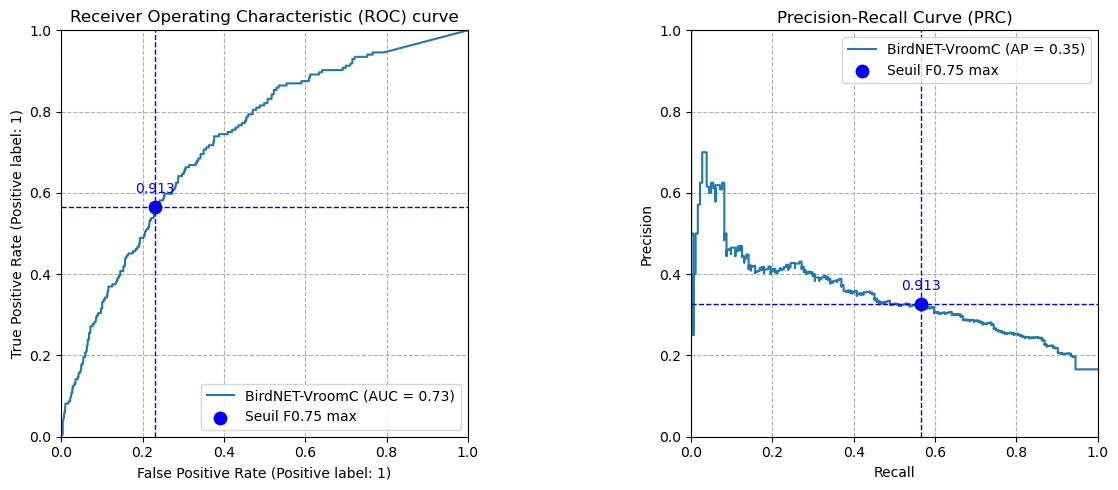

Seuil F0.75 max : 0.9131 | F0.75-score : 0.3855 | Précision : 0.3270 | Rappel : 0.5652
Point F0.75 max sur ROC : TPR : 0.5652 | FPR : 0.2311


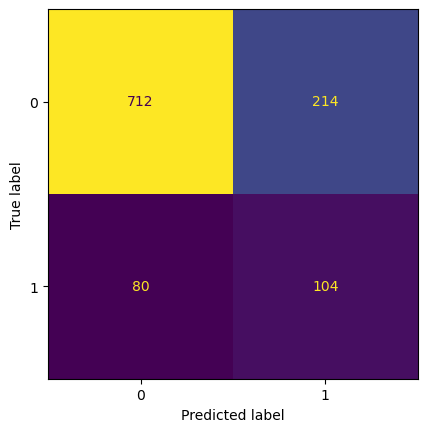

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, precision_score,    f1_score

df_temp=df_reduit_vn

# Données
y_true = df_temp['trueEngine']
y_scores = df_temp['Confidence']

# 1. Seuil optimal F1 (PRC)
precision, recall, thresholds_prc = precision_recall_curve(y_true, y_scores)
f_scores = (1+(0.75**2)) * precision[:-1] * recall[:-1] / ((0.75**2)*precision[:-1] + recall[:-1] + 1e-8)
ix_f_opt = np.argmax(f_scores)
seuil_f_opt = thresholds_prc[ix_f_opt]
precision_f = precision[ix_f_opt]
recall_f = recall[ix_f_opt]
f_opt = f_scores[ix_f_opt]

# 2. Seuil optimal Youden (ROC)
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
J = tpr - fpr
ix_youden = np.argmax(J)
seuil_youden = thresholds_roc[ix_youden]
fpr_youden = fpr[ix_youden]
tpr_youden = tpr[ix_youden]

# 3. Correspondance des seuils sur l'autre courbe
# F1 sur ROC
ix_roc_f = np.argmin(np.abs(thresholds_roc - seuil_f_opt))
fpr_f1 = fpr[ix_roc_f]
tpr_f1 = tpr[ix_roc_f]
# Youden sur PRC
ix_prc_youden = np.argmin(np.abs(thresholds_prc - seuil_youden))
precision_youden = precision[ix_prc_youden]
recall_youden = recall[ix_prc_youden]

# 4. Affichage
fig, (ax_roc, ax_prc) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(y_true, y_scores, ax=ax_roc, name="BirdNET-VroomC")
ax_roc.scatter(fpr_f1, tpr_f1, color='blue', s=80, label='Seuil F0.75 max', zorder=5)
# ax_roc.scatter(fpr_youden, tpr_youden, color='red', s=80, label='Seuil Youden', zorder=5)
ax_roc.axvline(fpr_f1, color='blue', linestyle='--', linewidth=1)
ax_roc.axhline(tpr_f1, color='blue', linestyle='--', linewidth=1)
# ax_roc.axvline(fpr_youden, color='red', linestyle='--', linewidth=1)
# ax_roc.axhline(tpr_youden, color='red', linestyle='--', linewidth=1)
ax_roc.annotate(f'{seuil_f_opt:.3f}', (fpr_f1, tpr_f1), textcoords="offset points", xytext=(0,10), ha='center', color='blue')
# ax_roc.annotate(f'{seuil_youden:.3f}', (fpr_youden, tpr_youden), textcoords="offset points", xytext=(0,-15), ha='center', color='red')
ax_roc.set_title("Receiver Operating Characteristic (ROC) curve")
ax_roc.grid(linestyle="--")
ax_roc.set_ylim(0,1)
ax_roc.set_xlim(0,1)
ax_roc.legend()

# PRC curve
PrecisionRecallDisplay.from_predictions(y_true, y_scores, ax=ax_prc, name="BirdNET-VroomC")
ax_prc.scatter(recall_f, precision_f, color='blue', s=80, label='Seuil F0.75 max', zorder=5)
# ax_prc.scatter(recall_youden, precision_youden, color='red', s=80, label='Seuil Youden', zorder=5)
ax_prc.axvline(recall_f, color='blue', linestyle='--', linewidth=1)
ax_prc.axhline(precision_f, color='blue', linestyle='--', linewidth=1)
# ax_prc.axvline(recall_youden, color='red', linestyle='--', linewidth=1)
# ax_prc.axhline(precision_youden, color='red', linestyle='--', linewidth=1)
ax_prc.annotate(f'{seuil_f_opt:.3f}', (recall_f, precision_f), textcoords="offset points", xytext=(0,10), ha='center', color='blue')
# ax_prc.annotate(f'{seuil_youden:.3f}', (recall_youden, precision_youden), textcoords="offset points", xytext=(0,-15), ha='center', color='red')
ax_prc.set_title("Precision-Recall Curve (PRC)")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.grid(linestyle="--")
ax_prc.set_ylim(0,1)
ax_prc.set_xlim(0,1)
ax_prc.legend()

plt.tight_layout()
plt.show()

# 5. Affichage des seuils et métriques
print(f"Seuil F0.75 max : {seuil_f_opt:.4f} | F0.75-score : {f_opt:.4f} | Précision : {precision_f:.4f} | Rappel : {recall_f:.4f}")
print(f"Point F0.75 max sur ROC : TPR : {tpr_f1:.4f} | FPR : {fpr_f1:.4f}")

y_pred_f = (y_scores >= seuil_f_opt).astype(int)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred_f,  colorbar= False)

In [12]:
preds_vnc = pd.read_csv(MODEL_PREDS + "/vehicle_engine_c-audio3s.csv",sep=',')
df_vnc = pd.merge(annot_perfile,preds_vnc,on='filename')


In [13]:
df_temp = df_vnc
df_temp['basefile'] = 'rien'
for i in range(len(df_temp)):
    df_temp.loc[i,'basefile']= df_temp.loc[i,'filename'][:-8]
cols = ['Engine', 'Confidence','trueEngine']
df_reduit_vnc= df_temp.groupby('basefile')[cols].max().reset_index()

In [20]:
df_vnc.to_csv('vehicle_engine_c-audio3s.csv')

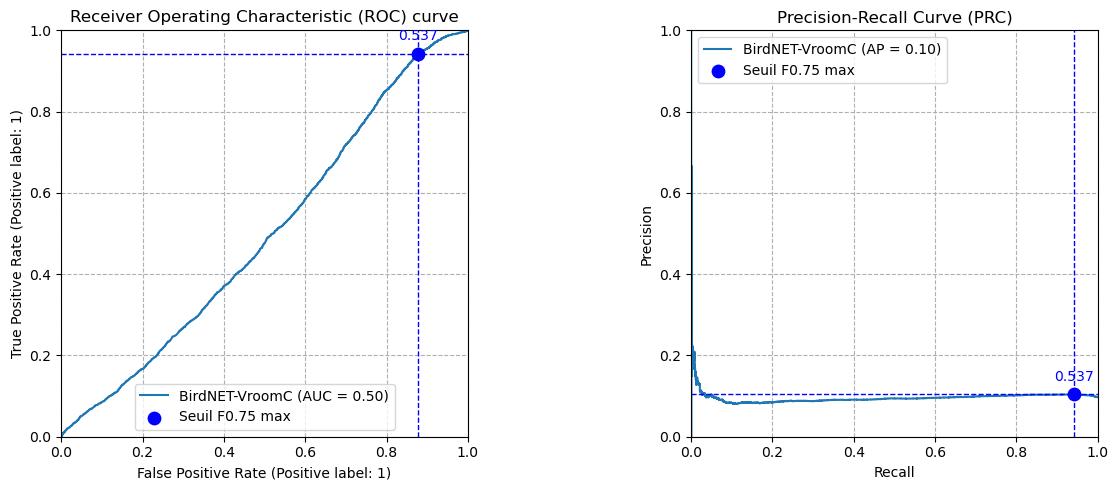

Seuil F0.75 max : 0.5373 | F0.75-score : 0.1532 | Précision : 0.1041 | Rappel : 0.9423
Point F0.75 max sur ROC : TPR : 0.9423 | FPR : 0.8770


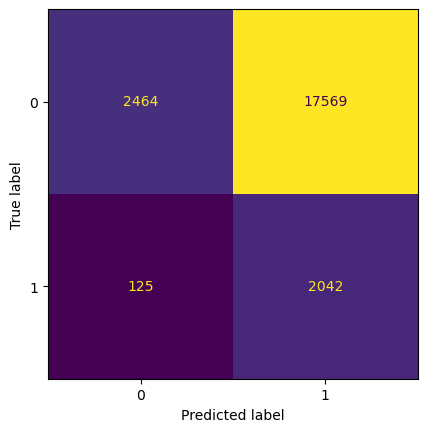

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, precision_score,    f1_score

df_temp=df_vnc

# Données
y_true = df_temp['trueEngine']
y_scores = df_temp['Confidence']

# 1. Seuil optimal F1 (PRC)
precision, recall, thresholds_prc = precision_recall_curve(y_true, y_scores)
f_scores = (1+(0.75**2)) * precision[:-1] * recall[:-1] / ((0.75**2)*precision[:-1] + recall[:-1] + 1e-8)
ix_f_opt = np.argmax(f_scores)
seuil_f_opt = thresholds_prc[ix_f_opt]
precision_f = precision[ix_f_opt]
recall_f = recall[ix_f_opt]
f_opt = f_scores[ix_f_opt]

# 2. Seuil optimal Youden (ROC)
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
J = tpr - fpr
ix_youden = np.argmax(J)
seuil_youden = thresholds_roc[ix_youden]
fpr_youden = fpr[ix_youden]
tpr_youden = tpr[ix_youden]

# 3. Correspondance des seuils sur l'autre courbe
# F1 sur ROC
ix_roc_f = np.argmin(np.abs(thresholds_roc - seuil_f_opt))
fpr_f1 = fpr[ix_roc_f]
tpr_f1 = tpr[ix_roc_f]
# Youden sur PRC
ix_prc_youden = np.argmin(np.abs(thresholds_prc - seuil_youden))
precision_youden = precision[ix_prc_youden]
recall_youden = recall[ix_prc_youden]

# 4. Affichage
fig, (ax_roc, ax_prc) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(y_true, y_scores, ax=ax_roc, name="BirdNET-VroomC")
ax_roc.scatter(fpr_f1, tpr_f1, color='blue', s=80, label='Seuil F0.75 max', zorder=5)
# ax_roc.scatter(fpr_youden, tpr_youden, color='red', s=80, label='Seuil Youden', zorder=5)
ax_roc.axvline(fpr_f1, color='blue', linestyle='--', linewidth=1)
ax_roc.axhline(tpr_f1, color='blue', linestyle='--', linewidth=1)
# ax_roc.axvline(fpr_youden, color='red', linestyle='--', linewidth=1)
# ax_roc.axhline(tpr_youden, color='red', linestyle='--', linewidth=1)
ax_roc.annotate(f'{seuil_f_opt:.3f}', (fpr_f1, tpr_f1), textcoords="offset points", xytext=(0,10), ha='center', color='blue')
# ax_roc.annotate(f'{seuil_youden:.3f}', (fpr_youden, tpr_youden), textcoords="offset points", xytext=(0,-15), ha='center', color='red')
ax_roc.set_title("Receiver Operating Characteristic (ROC) curve")
ax_roc.grid(linestyle="--")
ax_roc.set_ylim(0,1)
ax_roc.set_xlim(0,1)
ax_roc.legend()

# PRC curve
PrecisionRecallDisplay.from_predictions(y_true, y_scores, ax=ax_prc, name="BirdNET-VroomC")
ax_prc.scatter(recall_f, precision_f, color='blue', s=80, label='Seuil F0.75 max', zorder=5)
# ax_prc.scatter(recall_youden, precision_youden, color='red', s=80, label='Seuil Youden', zorder=5)
ax_prc.axvline(recall_f, color='blue', linestyle='--', linewidth=1)
ax_prc.axhline(precision_f, color='blue', linestyle='--', linewidth=1)
# ax_prc.axvline(recall_youden, color='red', linestyle='--', linewidth=1)
# ax_prc.axhline(precision_youden, color='red', linestyle='--', linewidth=1)
ax_prc.annotate(f'{seuil_f_opt:.3f}', (recall_f, precision_f), textcoords="offset points", xytext=(0,10), ha='center', color='blue')
# ax_prc.annotate(f'{seuil_youden:.3f}', (recall_youden, precision_youden), textcoords="offset points", xytext=(0,-15), ha='center', color='red')
ax_prc.set_title("Precision-Recall Curve (PRC)")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.grid(linestyle="--")
ax_prc.set_ylim(0,1)
ax_prc.set_xlim(0,1)
ax_prc.legend()

plt.tight_layout()
plt.show()

# 5. Affichage des seuils et métriques
print(f"Seuil F0.75 max : {seuil_f_opt:.4f} | F0.75-score : {f_opt:.4f} | Précision : {precision_f:.4f} | Rappel : {recall_f:.4f}")
print(f"Point F0.75 max sur ROC : TPR : {tpr_f1:.4f} | FPR : {fpr_f1:.4f}")

y_pred_f = (y_scores >= seuil_f_opt).astype(int)

ConfusionMatrixDisplay.from_predictions(y_true, y_pred_f,  colorbar= False)